# Scheduling in Your Domain

**Assignment 04 - Lesson 9: Scheduling and Time-Based Decisions**  
**Student Name:** Trevor Tilley
**Date:** 04-07-2026  
**Chosen context:** Security Operations Center (SOC) analysts across eight time periods representing a 24-hour cycle divided into shifts.

---

## Introduction


In [24]:
# Install required packages (if needed in Colab)
# Skip if running locally and packages are already installed
%pip install pulp pandas matplotlib -q

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from pulp import LpProblem, LpMinimize, LpMaximize, LpVariable, lpSum, value, LpStatus
import io

print("Libraries imported successfully!")

Libraries imported successfully!


## Section 1 - Choose Your Domain and Scheduling Problem

This model schedules Security Operations Center (SOC) analysts across eight time periods representing a 24-hour cycle divided into shifts. The objective is to ensure sufficient analyst coverage to handle expected security alert demand while minimizing total staffing cost. Each shift has a required minimum number of analysts based on projected alert volume, and the model determines optimal staffing levels under resource constraints.

## Section 2 - Define the Schedule Structure

**Time Periods:**
The schedule is divided into 8 time periods representing 3-hour shifts across a 24-hour cycle (Shift_1 through Shift_8).

**Resources Being Scheduled:**
Security Operations Center (SOC) analysts responsible for monitoring and responding to security alerts.

**Demand Requirements:**
Each time period has a minimum number of analysts required based on expected alert volume. Demand is higher during peak operational hours and lower during off-peak periods.


### 2.1 LLM Steps for Synthetic Data

ChatGPT was used to generate a synthetic dataset representing SOC analyst demand and cost per shift across eight time periods.

In [26]:
# Paste your synthetic CSV in csv_string (replace sample values)
csv_string = """
time_period,demand_required,cost_per_unit
Shift_1,3,40
Shift_2,4,42
Shift_3,6,45
Shift_4,7,50
Shift_5,8,55
Shift_6,6,50
Shift_7,5,45
Shift_8,4,42
"""

schedule_df = pd.read_csv(io.StringIO(csv_string.strip()))
display(schedule_df)
print(f"Number of periods: {len(schedule_df)}")

,time_period,demand_required,cost_per_unit
0,Shift_1,3,40
1,Shift_2,4,42
2,Shift_3,6,45
3,Shift_4,7,50
4,Shift_5,8,55
5,Shift_6,6,50
6,Shift_7,5,45
7,Shift_8,4,42


Number of periods: 8


In [27]:
# Optional planning table for your schedule structure
# TODO: Replace placeholder text with your domain-specific definitions
structure_df = pd.DataFrame([
    {"item": "Resources being scheduled", "definition": "Security Operations Center (SOC) analysts"},
    {"item": "Time unit", "definition": "3-hour shifts across a 24-hour period"},
    {"item": "Coverage meaning", "definition": "Minimum number of analysts required"},
    {"item": "Objective", "definition": "Minimize total staffing cost"}
])
structure_df

,item,definition
0,Resources being scheduled,Security Operations Center (SOC) analysts
1,Time unit,3-hour shifts across a 24-hour period
2,Coverage meaning,Minimum number of analysts required
3,Objective,Minimize total staffing cost


## Section 3 - Build and Solve the Scheduling Model

Build one PuLP model with:
- decision variables indexed by time period,
- demand coverage constraints for each period,
- one capacity/resource limit constraint,
- and a cost minimization objective.

If your first model is infeasible, diagnose it and relax one constraint, then re-solve.

In [28]:
# Build and solve the SOC scheduling model

# Time periods
periods = schedule_df["time_period"].tolist()

# Parameters
demand = dict(zip(schedule_df["time_period"], schedule_df["demand_required"]))
cost = dict(zip(schedule_df["time_period"], schedule_df["cost_per_unit"]))

# SOC workforce capacity (total analysts available across all shifts)
# Example: assume 45 total analyst-shift assignments available
total_capacity_limit = 45

# Model
base_model = LpProblem("SOC_Analyst_Scheduling", LpMinimize)

# Decision variables (INTEGER = whole analysts)
scheduled = {
    p: LpVariable(f"analysts_{p}", lowBound=0, cat='Integer')
    for p in periods
}

# Objective: minimize total staffing cost
base_model += lpSum(scheduled[p] * cost[p] for p in periods), "Total_Staffing_Cost"

# Coverage constraints: each shift must meet required analyst demand
for p in periods:
    base_model += scheduled[p] >= demand[p], f"Coverage_{p}"

# Capacity constraint: total analysts across all shifts limited
base_model += lpSum(scheduled[p] for p in periods) <= total_capacity_limit, "Total_Analyst_Capacity"

# Solve
base_model.solve()

# Output
print(f"Status: {LpStatus[base_model.status]}")
print(f"Total cost: {value(base_model.objective):.2f}")

# Results DataFrame
base_solution_df = pd.DataFrame({
    "time_period": periods,
    "demand_required": [demand[p] for p in periods],
    "analysts_assigned": [value(scheduled[p]) for p in periods],
    "cost_per_unit": [cost[p] for p in periods]
})

display(base_solution_df)

Status: Optimal
Total cost: 2041.00


,time_period,demand_required,analysts_assigned,cost_per_unit
0,Shift_1,3,3.0,40
1,Shift_2,4,4.0,42
2,Shift_3,6,6.0,45
3,Shift_4,7,7.0,50
4,Shift_5,8,8.0,55
5,Shift_6,6,6.0,50
6,Shift_7,5,5.0,45
7,Shift_8,4,4.0,42


### 3.1 Interpret the Base Schedule

The hardest periods to cover are the mid-cycle shifts (Shift_4 and Shift_5), where demand for analysts is highest due to increased security alert activity. The total capacity is relatively tough, as the model assigns analysts at or near the minimum required levels without significant excess staffing. From a management perspective, the key takeaway is that the current staffing plan meets all demand requirements at the lowest possible cost, but leaves little buffer for unexpected spikes in alerts. This suggests a potential risk if incident volume exceeds projections.

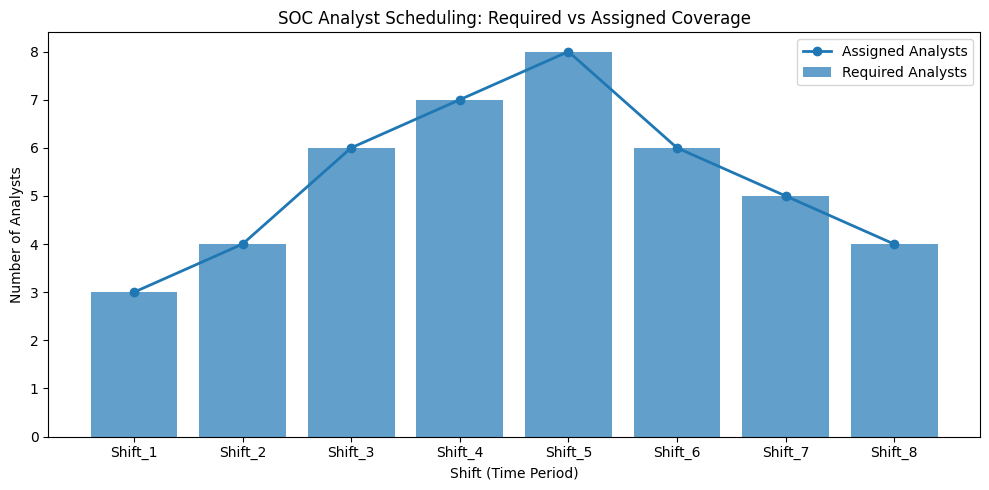

In [29]:
# Visualization: SOC analyst coverage (required vs assigned)

plt.figure(figsize=(10, 5))

x = range(len(base_solution_df))

# Bar = required analysts (demand)
plt.bar(x, base_solution_df["demand_required"], alpha=0.7, label="Required Analysts")

# Line = assigned analysts (model output)
plt.plot(x, base_solution_df["analysts_assigned"], marker="o", linewidth=2, label="Assigned Analysts")

# Formatting
plt.xticks(x, base_solution_df["time_period"])
plt.xlabel("Shift (Time Period)")
plt.ylabel("Number of Analysts")
plt.title("SOC Analyst Scheduling: Required vs Assigned Coverage")
plt.legend()
plt.tight_layout()

plt.show()

## Section 4 - Cost vs Service Tradeoff Analysis

Run one what-if scenario and compare against your base model.

Examples:
- tighter budget/capacity,
- higher coverage requirement,
- changed period demand pattern.

In [30]:
# What-if scenario: increased security coverage (+1 analyst per shift)

# Updated demand (adds buffer for unexpected alerts)
demand_tradeoff = {p: demand[p] + 1 for p in periods}

# New model
tradeoff_model = LpProblem("SOC_Tradeoff_Model", LpMinimize)

# Decision variables (INTEGER analysts)
scheduled_tradeoff = {
    p: LpVariable(f"analysts_tradeoff_{p}", lowBound=0, cat='Integer')
    for p in periods
}

# Objective: minimize cost
tradeoff_model += lpSum(scheduled_tradeoff[p] * cost[p] for p in periods), "Total_Staffing_Cost_Tradeoff"

# Coverage constraints (higher requirement)
for p in periods:
    tradeoff_model += scheduled_tradeoff[p] >= demand_tradeoff[p], f"Coverage_Tradeoff_{p}"

# Same capacity constraint for fair comparison
tradeoff_model += lpSum(scheduled_tradeoff[p] for p in periods) <= total_capacity_limit, "Total_Capacity_Tradeoff"

# Solve
tradeoff_model.solve()

# Results
tradeoff_solution_df = pd.DataFrame({
    "time_period": periods,
    "analysts_assigned_tradeoff": [value(scheduled_tradeoff[p]) for p in periods]
})

# Comparison table
comparison_df = base_solution_df.merge(
    tradeoff_solution_df, on="time_period"
)

# Costs
base_cost = value(base_model.objective)
tradeoff_cost = value(tradeoff_model.objective)

print(f"Base status: {LpStatus[base_model.status]} | Base total cost: {base_cost:.2f}")
print(f"Tradeoff status: {LpStatus[tradeoff_model.status]} | Tradeoff total cost: {tradeoff_cost:.2f}")

display(comparison_df)

Base status: Optimal | Base total cost: 2041.00
Tradeoff status: Infeasible | Tradeoff total cost: 2410.00


,time_period,demand_required,analysts_assigned,cost_per_unit,analysts_assigned_tradeoff
0,Shift_1,3,3.0,40,4.0
1,Shift_2,4,4.0,42,5.0
2,Shift_3,6,6.0,45,7.0
3,Shift_4,7,7.0,50,8.0
4,Shift_5,8,8.0,55,9.0
5,Shift_6,6,6.0,50,7.0
6,Shift_7,5,5.0,45,6.0
7,Shift_8,4,4.0,42,5.0


The what-if scenario increases analyst coverage by one additional analyst per shift to provide a buffer against unexpected spikes in security alerts. This results in higher total staffing costs compared to the base model, but improves service reliability and reduces the risk of missed or delayed incident responses. The tradeoff highlights that increasing security readiness requires additional investment, and management must balance cost efficiency with risk tolerance.

## Section 5 - Stakeholder Change and Reflection

Choose one stakeholder change:
- **(a)** Fairness constraint: no single period receives more than X% of total scheduled load.
- **(b)** Higher minimum coverage floor than base requirement.
- **(c)** Change objective from cost minimization to service maximization.

Update your model, solve, and compare with one visualization.

In [31]:
# Stakeholder change: increase minimum coverage to ensure extra safety buffer
# e.g., all shifts must have at least 2 more analysts than base demand

floor_increase = 2  # stakeholder requirement

stakeholder_model = LpProblem("SOC_Stakeholder_HigherFloor", LpMinimize)

# Decision variables (INTEGER)
scheduled_stakeholder = {
    p: LpVariable(f"analysts_stakeholder_{p}", lowBound=0, cat='Integer')
    for p in periods
}

# Objective: still minimize cost
stakeholder_model += lpSum(scheduled_stakeholder[p] * cost[p] for p in periods), "Total_Staffing_Cost_Stakeholder"

# Coverage constraints: base demand + stakeholder floor
for p in periods:
    stakeholder_model += scheduled_stakeholder[p] >= demand[p] + floor_increase, f"Coverage_Stakeholder_{p}"

# Capacity constraint: same as before
stakeholder_model += lpSum(scheduled_stakeholder[p] for p in periods) <= total_capacity_limit, "Total_Capacity_Stakeholder"

# Solve model
stakeholder_model.solve()

# Results DataFrame
stakeholder_solution_df = pd.DataFrame({
    "time_period": periods,
    "analysts_stakeholder": [value(scheduled_stakeholder[p]) for p in periods]
})

# Merge all scenarios for comparison
final_compare_df = comparison_df.merge(stakeholder_solution_df, on="time_period")

print(f"Stakeholder status: {LpStatus[stakeholder_model.status]}")
if stakeholder_model.status == 1:
    print(f"Stakeholder total cost: {value(stakeholder_model.objective):.2f}")
display(final_compare_df)

Stakeholder status: Infeasible


,time_period,demand_required,analysts_assigned,cost_per_unit,analysts_assigned_tradeoff,analysts_stakeholder
0,Shift_1,3,3.0,40,4.0,5.0
1,Shift_2,4,4.0,42,5.0,6.0
2,Shift_3,6,6.0,45,7.0,8.0
3,Shift_4,7,7.0,50,8.0,9.0
4,Shift_5,8,8.0,55,9.0,10.0
5,Shift_6,6,6.0,50,7.0,8.0
6,Shift_7,5,5.0,45,6.0,7.0
7,Shift_8,4,4.0,42,5.0,6.0


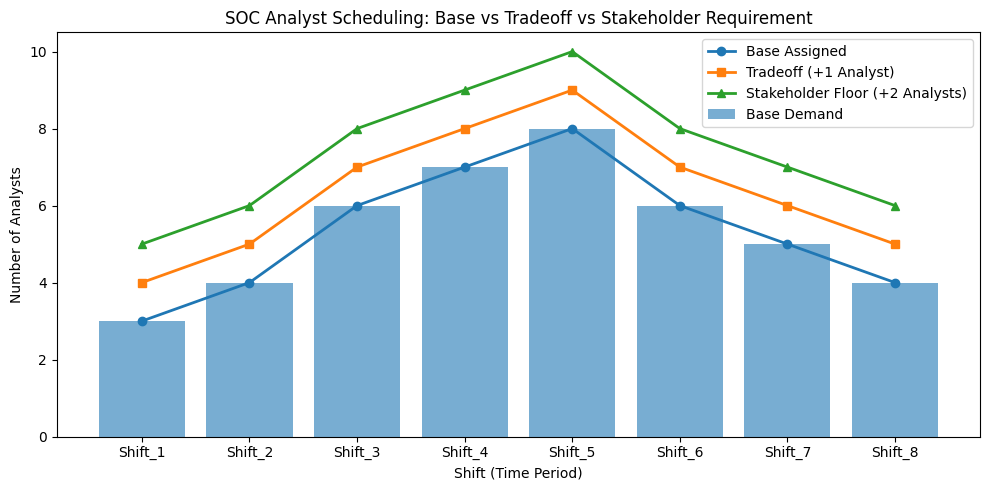

In [32]:
plt.figure(figsize=(10,5))
x = range(len(final_compare_df))

plt.bar(x, final_compare_df["demand_required"], alpha=0.6, label="Base Demand")
plt.plot(x, final_compare_df["analysts_assigned"], marker="o", linewidth=2, label="Base Assigned")
plt.plot(x, final_compare_df["analysts_assigned_tradeoff"], marker="s", linewidth=2, label="Tradeoff (+1 Analyst)")
plt.plot(x, final_compare_df["analysts_stakeholder"], marker="^", linewidth=2, label="Stakeholder Floor (+2 Analysts)")

plt.xticks(x, final_compare_df["time_period"])
plt.xlabel("Shift (Time Period)")
plt.ylabel("Number of Analysts")
plt.title("SOC Analyst Scheduling: Base vs Tradeoff vs Stakeholder Requirement")
plt.legend()
plt.tight_layout()
plt.show()

### 5.1 Stakeholder Change Interpretation

Increasing the minimum coverage requirement by two analysts per shift caused every shift to have more analysts than in the base schedule. High-demand periods, such as Shift_4 and Shift_5, now receive additional staffing, ensuring that unexpected spikes in security alerts can be handled without delay. Total staffing costs increased as a result, and the schedule approaches the overall limit.

This change matters for decision-making because it shows the tradeoff between reliability and cost. You can clearly see that meeting higher coverage requirements improves security readiness but requires additional resources and budget. The analysis highlights the importance of balancing risk, staffing availability, and financial constraints when doing scheduling.

### 5.2 Professional Reflection

In my scenario, I increased the minimum number of analysts for each shift by 1-2, which meant that every period now had more coverage than in the base schedule. The busiest shifts saw the largest increases, and total staffing costs went up as a result. The schedule also got closer to our capacity, which suggests that if we wanted to maintain this higher coverage long-term, we might need to hire additional analysts or increase the budget.

This change matters because it directly affects how well the SOC can respond to unexpected spikes in alerts. With more analysts on duty, the team is better prepared to handle incidents without delays, reducing risk. For management, it’s a clear example of the tradeoff between reliability and cost. Better coverage increases confidence in security response but requires more resources.

One key takeaway from this exercise is that time-based scheduling is different from simple resource allocation. It’s not just about how many people are available, but when they are available and how that aligns with the demand over time. Modeling these constraints shows why scheduling requires planning to balance workload, coverage, and capacity across the day or shift cycle.

---
## Expectations: What to Check Before Submitting

Run through this checklist before you submit:

- **Model execution:** Base model and stakeholder-change model run without errors; infeasibility is handled clearly if encountered.
- **Visualization quality:** At least one schedule visualization has clear title, axis labels, and is referenced in your text.
- **Stakeholder section complete:** One stakeholder change implemented, solved, and compared to base.
- **Writing quality:** Clear, professional, non-technical explanation where requested; no leftover bare `[TODO]` in final submission.
- **GitHub readiness:** Notebook is committed, repository link is accessible, and materials are organized.

The rubric used for grading is provided separately.